In [ ]:
import pandas as pd
df = pd.read_csv("train11143033.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
import pandas as pd                      
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier     
import numpy as np                       

# 1. 讀取鐵達尼號訓練資料
df = pd.read_csv("train11143033.csv")           

# 2. 選擇符合原始程式碼數值特徵的欄位，並加上目標變數
# 原始程式碼主要處理數值欄位，因此我們選取數值特徵：Pclass, Age, SibSp, Parch, Fare
# 選擇 'Survived' (生存結果) 作為目標，以及 Pclass, Age, SibSp, Parch, Fare 五個數值特徵
titanic_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# 3. **移除所有缺失值 (符合原始程式碼的 `dropna()` 邏輯)**
# 移除所有含有 NaN (Not a Number, 缺失值) 的行。
# 由於 'Age' 欄位有許多缺失值，這一步會導致這些行被移除。
new_df = titanic_df.dropna() 

# 4. **依據欄位篩選資料 (平移原始程式碼的 `BloodPressure > 0` 邏輯)**
# 篩選資料，只保留 'Fare' (票價) 大於 0 的記錄。
# 為了模擬原始糖尿病程式碼中「移除不合理零值」的意圖。
new_df = new_df[new_df["Fare"] > 0]

# 5. **處理特定欄位的異常值**
# 對 'Fare' (票價) 執行 IQR (Interquartile Range, 四分位距) 來移除極端異常值。
# 
Q3 = new_df["Fare"].quantile(0.75)  # 計算票價的第三四分位數 (Q3)
Q1 = new_df["Fare"].quantile(0.25)  # 計算票價的第一四分位數 (Q1)
iqr = Q3 - Q1                       # 計算四分位距 (IQR)
upper = Q3 + 1.5 * iqr              # 計算異常值上限 (Q3 + 1.5 * IQR)
lower = Q1 - 1.5 * iqr              # 計算異常值下限 (Q1 - 1.5 * IQR)

# 移除票價超過 IQR 上限或下限的極端值
final_df = new_df[(new_df["Fare"] >= lower) & (new_df["Fare"] <= upper)].copy()

print(f"原始資料筆數: {len(df)}")    # 輸出原始資料的行數
print(f"清理後資料筆數: {len(final_df)}") # 輸出經過缺失值移除和異常值篩選後的資料行數

# 6. 定義 X (特徵) 和 y (目標)
y = final_df["Survived"]            # 將 'Survived' (生存結果) 欄位定義為目標變數 y (模型要預測的結果)
# X 為所有特徵 (移除 Survived 欄位)
X = final_df.drop(columns=["Survived"]) # 將除了 'Survived' 以外的所有欄位定義為特徵 X (模型用來學習的輸入資料)

# 資料切分成訓練與測試
# 將 X 和 y 切割成訓練集 (X_train, y_train) 和測試集 (X_test, y_test)。
# test_size=0.3 表示 30% 的資料用於測試，70% 用於訓練。
# random_state=45 確保每次運行時切割結果都相同，以便重現結果。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=45)

# 建立決策樹模型
# 建立一個決策樹分類器模型實例。random_state=42 用於固定模型訓練過程的隨機性。
model_tree = DecisionTreeClassifier(random_state=42)

# 開始訓練模型
# 使用訓練集 (X_train, y_train) 來訓練決策樹模型，讓模型從資料中學習規律。
model_tree.fit(X_train, y_train)

# 計算正確率
# 使用測試集 (X_test, y_test) 來評估模型性能，返回模型在測試集上的分類準確度 (Accuracy)。
score = model_tree.score(X_test, y_test)

print("--- 最後結果 ---")
print(f"決策樹模型在鐵達尼號資料上的準確度 : {score:.4f}") # 輸出最終的準確度，保留四位小數。

原始資料筆數: 891
清理後資料筆數: 613
--- 最後結果 ---
決策樹模型在鐵達尼號資料上的準確度 : 0.6576


In [13]:
import pandas as pd                     
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier      
from sklearn.preprocessing import StandardScaler     
from sklearn.linear_model import LogisticRegression   
from sklearn.metrics import accuracy_score           
import numpy as np                      


# 1. 資料讀取與清理 (資料前處理)

# 讀取鐵達尼號訓練資料
df = pd.read_csv("train.csv")            # 讀取名為 "train.csv" 的資料集

# 選擇數值特徵與目標變數
# 選擇 'Survived' (目標) 與五個數值特徵作為建模的輸入資料。
titanic_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# 移除所有缺失值 
new_df = titanic_df.dropna()             # 移除任何包含缺失值 (NaN) 的行

# 篩選資料：Fare (票價) 必須大於 0
# 保留 'Fare' (票價) 大於 0 的記錄，移除票價為 0 的記錄
new_df = new_df[new_df["Fare"] > 0]

# 處理特定欄位 (Fare) 的 IQR 異常值
# 以下步驟使用 IQR (四分位距) 方法來計算並移除 'Fare' 欄位中的極端離群值。
Q3 = new_df["Fare"].quantile(0.75)       # 計算 Q3 (第三四分位數)
Q1 = new_df["Fare"].quantile(0.25)       # 計算 Q1 (第一四分位數)
# upper = Q3 + 1.5 * IQR； lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * (Q3 - Q1)
lower = Q1 - 1.5 * (Q3 - Q1)
# 移除票價超過 IQR 上限的極端值，保留在合理範圍內的數據。
final_df = new_df[(new_df["Fare"] >= lower) & (new_df["Fare"] <= upper)].copy()

# 定義 X (特徵) 和 y (目標)
y = final_df["Survived"]            # 將 'Survived' 設為目標變數 y (模型要預測的結果)
X = final_df.drop(columns=["Survived"]) # 將除了 'Survived' 以外的所有欄位設為特徵 X (模型學習的輸入)

# 資料切分成訓練與測試
# 將資料分成 70% 的訓練集 (X_train, y_train) 和 30% 的測試集 (X_test, y_test)。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=45)

# =========================================================
# 2. 資料標準化 (Standardization) 
# 這是邏輯迴歸等線性模型重要的步驟，能避免數值範圍差異過大的特徵主導模型。
# =========================================================

# 建立標準化 (StandardScaler) 實例
scaler = StandardScaler()                # 建立一個標準化處理器物件

# 使用訓練資料 (X_train) 進行 fit (計算平均值與標準差) 和 transform (轉換)
# 'fit' 讓 scaler 學習訓練資料集的均值和標準差；'transform' 則應用這些參數進行標準化 (Z-Score)。
X_train_scaled = scaler.fit_transform(X_train)

# 使用訓練資料 fit 好的 scaler 來轉換測試資料
# 測試資料必須使用訓練資料計算出的均值和標準差來轉換，以避免數據洩露。
X_test_scaled = scaler.transform(X_test)

# (將 NumPy 陣列轉換回帶有欄位名稱的 DataFrame，方便查看)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("--- 標準化後的訓練集資料 (前五筆) ---")
print(X_train_scaled_df.head()) # 輸出標準化後 (均值為 0, 標準差為 1) 的數據


# 3. 模型訓練 (使用 Logistic Regression) 


# 使用 Logistic Regression (邏輯迴歸) 作為模型實例
model_scaled = LogisticRegression(random_state=42) # 建立邏輯迴歸模型物件

# 使用標準化後的訓練集進行模型訓練
# 使用已標準化 (X_train_scaled) 的特徵來訓練模型。
model_scaled.fit(X_train_scaled, y_train)

# 4. 評估模型
# 使用標準化後的測試集進行預測
y_pred_scaled = model_scaled.predict(X_test_scaled)

# 計算模型的準確度
# 比較模型的預測結果 (y_pred_scaled) 與實際結果 (y_test) 的準確度。
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# 5. 結果輸出

print("\n--- 最後結果 ---")
print(f"原始資料筆數: {len(df)}")
print(f"清理後資料筆數: {len(final_df)}")
print(f"\n標準化資料訓練的 Logistic Regression 模型準確度: {accuracy_scaled:.4f}") # 輸出最終模型準確度

--- 標準化後的訓練集資料 (前五筆) ---
     Pclass       Age     SibSp     Parch      Fare
0 -0.537770 -1.493308 -0.535842  1.868032  0.454001
1 -0.537770  2.063871 -0.535842 -0.478632 -0.423368
2 -0.537770  0.110910 -0.535842 -0.478632 -0.457775
3  0.795776  0.041161  0.485830  0.694700  0.309493
4  0.795776  2.203369 -0.535842 -0.478632 -0.923124

--- 最後結果 ---
原始資料筆數: 891
清理後資料筆數: 613

標準化資料訓練的 Logistic Regression 模型準確度: 0.7283



--- 排序後的特徵重要性 (Logistic Regression 係數絕對值) ---
  Feature  Importance
0  Pclass    0.954757
1     Age    0.837828
2   SibSp    0.336724
3   Parch    0.258705
4    Fare    0.055373


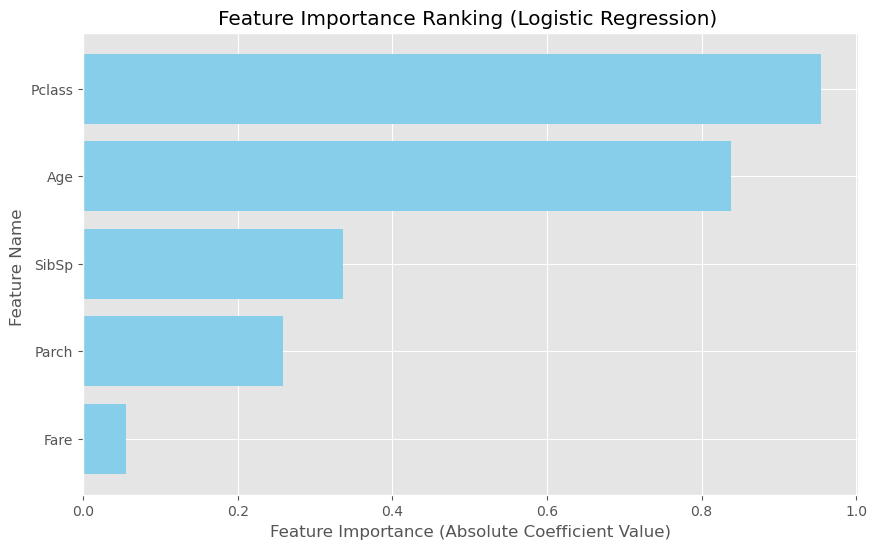

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # 繪圖函式庫 (Matplotlib)
import numpy as np


# =========================================================
# 1. 取得特徵名稱與模型係數
# =========================================================

# 取得訓練集中所有特徵的名稱 (X 欄位名稱)
feature_names = X.columns 

# 取得 Logistic Regression 模型的係數 (Coefficients)
coefficients = model_scaled.coef_[0]

# 2. 計算特徵重要性
# 使用係數的「絕對值」作為重要性指標。
importance = np.abs(coefficients)

# 3. 創建特徵重要性 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# 4. 依重要性由大到小排序
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', 
    ascending=False # 降冪排序 (由大到小)
)

print("\n--- 排序後的特徵重要性 (Logistic Regression 係數絕對值) ---")
print(feature_importance_df)

# =========================================================
# 5. 繪製特徵重要性柱狀圖 
# =========================================================

# 設定繪圖風格
plt.style.use('ggplot')

# 繪製水平柱狀圖
plt.figure(figsize=(10, 6))

# 使用排序好的 DataFrame 進行繪圖
plt.barh(
    feature_importance_df['Feature'], 
    feature_importance_df['Importance'], 
    color='skyblue'
)




plt.xlabel("Feature Importance (Absolute Coefficient Value)")  # 特徵重要性 (係數絕對值)
plt.ylabel("Feature Name ") # 特徵名稱
plt.title("Feature Importance Ranking (Logistic Regression) ") # 特徵重要性排序 (邏輯迴歸)
plt.gca().invert_yaxis() # 反轉 Y 軸，讓排序最高的特徵顯示在圖表最上方

# 顯示圖表
plt.show() # 顯示生成的圖表
#Pclass艙位等級
#Age年齡
#SibSp兄弟姊妹/配偶數
#Parch父母/子女數
#Fare票價


--- 特徵與生存結果 (Survived) 相關係數絕對值排序 ---
  Feature  Abs_Correlation
0  Pclass         0.286988
4    Fare         0.236382
1     Age         0.131361
3   Parch         0.096744
2   SibSp         0.029304


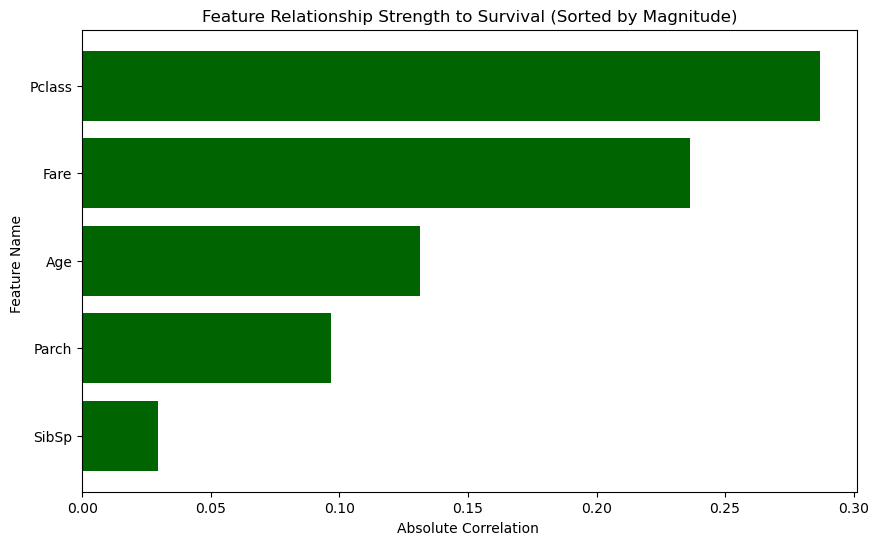

In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

# 假設您已經執行了前面的資料清理步驟，final_df 已經準備好

# =========================================================
# 1. 計算相關係數並取絕對值 (計算關係強度)
# =========================================================

# 計算所有欄位之間的相關係數矩陣
correlation_matrix = final_df.corr()

# 取得所有特徵與目標變數 'Survived' 之間的相關係數
survival_corr = correlation_matrix['Survived'].drop('Survived')

# 創建相關係數 DataFrame
correlation_df = pd.DataFrame(survival_corr).reset_index()
correlation_df.columns = ['Feature', 'Correlation']

# 2. 計算相關係數的「絕對值」作為重要性指標
correlation_df['Abs_Correlation'] = correlation_df['Correlation'].abs()

# 3. 依據絕對值 (Abs_Correlation) 由大到小排序
correlation_df = correlation_df.sort_values(
    by='Abs_Correlation', 
    ascending=False # 降冪排序 (由大到小)
)

print("\n--- 特徵與生存結果 (Survived) 相關係數絕對值排序 ---")
print(correlation_df[['Feature', 'Abs_Correlation']])

# =========================================================
# 4. 繪製簡潔版絕對值柱狀圖 
# =========================================================

# 由於同時使用中文和英文字符，為避免亂碼，我們再次配置字體：
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False # 解決負號亂碼問題

# 設定繪圖風格
plt.style.use('default') 

# 繪製水平柱狀圖
plt.figure(figsize=(10, 6))

# 使用 'Abs_Correlation' 絕對值作為柱長
plt.barh(
    correlation_df['Feature'], # Y 軸為特徵名稱
    correlation_df['Abs_Correlation'], # X 軸為絕對值強度 (0 到 1)
    color='darkgreen' # 使用單一顏色
)


# 加入標題和標籤 (使用英/中雙語標註)
plt.xlabel("Absolute Correlation ")# 絕對相關係數 (關係強度))
plt.ylabel("Feature Name ")#特徵名稱
plt.title("Feature Relationship Strength to Survival (Sorted by Magnitude)" ) # 特徵與生存結果的關係強度排序

# 反轉 Y 軸，確保排序最高的特徵在頂部
plt.gca().invert_yaxis() 

plt.show() # 顯示圖表

In [16]:
from scipy import stats  # 匯入科學運算庫中的統計模組

# 1. 資料分組：根據「生存與否」將票價 (Fare) 數據分成兩群
# 取得生存者 (Survived == 1) 的票價資料
survived = df[df['Survived'] == 1]['Fare']
# 取得遇難者 (Survived == 0) 的票價資料
not_survived = df[df['Survived'] == 0]['Fare']

# 2. 執行「獨立樣本 T 檢定」
# stats.ttest_ind 用於比較兩組獨立樣本的平均值是否有顯著差異
# equal_var=False：指定為 Welch's t-test，當兩組樣本數量或變異數不同時（如本案）較為準確
t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

# 3. 輸出初步統計結果
print(f"生存組平均票價: {survived.mean():.2f}")     # 格式化輸出到小數點後兩位
print(f"遇難組平均票價: {not_survived.mean():.2f}")
print(f"T 統計量 (t-statistic): {t_stat:.4f}")    # 代表兩組差異程度的數值
print(f"P 值 (p-value): {p_value:.4e}")           # 判斷顯著性的關鍵關鍵指標（科學記號格式）

# 4. 統計推論結果判斷
# 設定顯著水準 (Alpha) 為 0.05
if p_value < 0.05:
    print("【統計結論】：P 值小於 0.05，拒絕虛無假設。")
    print("這代表生存組與遇難者的票價在統計上有『顯著差異』，高票價與生存機率有正相關。")
else:
    print("【統計結論】：P 值大於 0.05，無法拒絕虛無假設。")
    print("這代表兩組之間的票價差異在統計上『不顯著』，可能是由隨機因素引起。")

生存組平均票價: 48.40
遇難組平均票價: 22.12
T 統計量 (t-statistic): 6.8391
P 值 (p-value): 2.6993e-11
【統計結論】：P 值小於 0.05，拒絕虛無假設。
這代表生存組與遇難者的票價在統計上有『顯著差異』，高票價與生存機率有正相關。


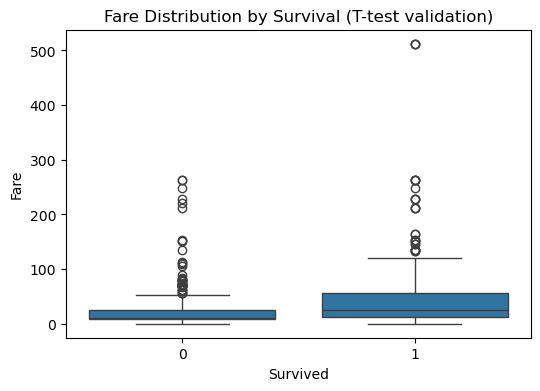

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival (T-test validation)')
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
import pandas as pd

# 1. 嚴格資料清洗：只選取需要的欄位，並立刻刪除任何含有空值 (NaN) 的行
# 這是為了解決你遇到的 ValueError 關鍵步驟
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
# 我們先建立一個包含特徵和目標的暫時資料表，然後把有缺洞的資料整行刪掉
df_clean = df[features + ['Survived']].dropna()

print(f"原始資料筆數: {len(df)}")
print(f"清洗(移除空值)後剩餘筆數: {len(df_clean)}")

# 2. 重新定義 X (特徵) 與 y (目標)
X = df_clean[features]
y = df_clean['Survived']

# 3. 切割資料集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 資料標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. 建立邏輯迴歸模型並執行 5 折交叉驗證
model_lr = LogisticRegression()
scores = cross_val_score(model_lr, X_train_scaled, y_train, cv=5)

# 6. 輸出結果
print("-" * 30)
print(f"各次交叉驗證準確度: {scores}")
print(f"平均準確度: {scores.mean():.4f}")

原始資料筆數: 891
清洗(移除空值)後剩餘筆數: 714
------------------------------
各次交叉驗證準確度: [0.75652174 0.66666667 0.69298246 0.6754386  0.72807018]
平均準確度: 0.7039
